To connect your Google Drive, you can use the `google.colab` library. This will prompt you to authenticate your Google account and grant Colab access to your Drive.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Once your Drive is mounted, you can access your files as if they were on a local file system. Here's how you can list the contents of your Drive. This example will list the contents of the root directory of your Google Drive.

In [1]:
import os

# List contents of the root of your Google Drive
drive_root_path = '/content/drive/MyDrive'

if os.path.exists(drive_root_path):
    print(f"Contents of '{drive_root_path}':")
    for item in os.listdir(drive_root_path):
        print(item)
else:
    print(f"'{drive_root_path}' not found. Please ensure Google Drive is mounted correctly.")

'/content/drive/MyDrive' not found. Please ensure Google Drive is mounted correctly.


In [3]:
import os
import zipfile

zip_file_path = '/content/drive/MyDrive/archive.zip'
extract_dir = 'unzipped_archive'

if not os.path.exists(extract_dir):
    os.makedirs(extract_dir)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"'{zip_file_path}' unzipped to '{extract_dir}' successfully.")
print(f"Contents of '{extract_dir}':")
for item in os.listdir(extract_dir):
    print(item)

'/content/drive/MyDrive/archive.zip' unzipped to 'unzipped_archive' successfully.
Contents of 'unzipped_archive':
OriginalDataset
AugmentedAlzheimerDataset


### Cell 1: Import libraries and load data

In [4]:
import numpy as np
import pandas as pd
import os

base_path = "unzipped_archive/AugmentedAlzheimerDataset/"
categories = ["MildDemented","ModerateDemented", "NonDemented", "VeryMildDemented"]

image_paths = []
labels = []

for category in categories:
    category_path = os.path.join(base_path, category)
    for image_name in os.listdir(category_path):
        image_path = os.path.join(category_path, image_name)
        image_paths.append(image_path)
        labels.append(category)

df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

### Cell 2: Explore data

In [5]:
display(df.head())

,image_path,label
0,unzipped_archive/AugmentedAlzheimerDataset/Mil...,MildDemented
1,unzipped_archive/AugmentedAlzheimerDataset/Mil...,MildDemented
2,unzipped_archive/AugmentedAlzheimerDataset/Mil...,MildDemented
3,unzipped_archive/AugmentedAlzheimerDataset/Mil...,MildDemented
4,unzipped_archive/AugmentedAlzheimerDataset/Mil...,MildDemented


### Cell 3: View last rows

In [6]:
display(df.tail())

,image_path,label
33979,unzipped_archive/AugmentedAlzheimerDataset/Ver...,VeryMildDemented
33980,unzipped_archive/AugmentedAlzheimerDataset/Ver...,VeryMildDemented
33981,unzipped_archive/AugmentedAlzheimerDataset/Ver...,VeryMildDemented
33982,unzipped_archive/AugmentedAlzheimerDataset/Ver...,VeryMildDemented
33983,unzipped_archive/AugmentedAlzheimerDataset/Ver...,VeryMildDemented


### Cell 4: Check shape

In [7]:
print(df.shape)

(33984, 2)


### Cell 5: Check columns

In [8]:
print(df.columns)

Index(['image_path', 'label'], dtype='object')


### Cell 6: Check duplicates

In [9]:
print(df.duplicated().sum())

0


### Cell 7: Check null values

In [10]:
print(df.isnull().sum())

image_path    0
label         0
dtype: int64


### Cell 8: Data info

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33984 entries, 0 to 33983
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  33984 non-null  object
 1   label       33984 non-null  object
dtypes: object(2)
memory usage: 531.1+ KB


### Cell 9: Check unique labels

In [12]:
print(df['label'].unique())

['MildDemented' 'ModerateDemented' 'NonDemented' 'VeryMildDemented']


### Cell 10: Value counts

In [13]:
print(df['label'].value_counts())

label
NonDemented         9600
MildDemented        8960
VeryMildDemented    8960
ModerateDemented    6464
Name: count, dtype: int64


### Cell 11: Visualization setup and count plot

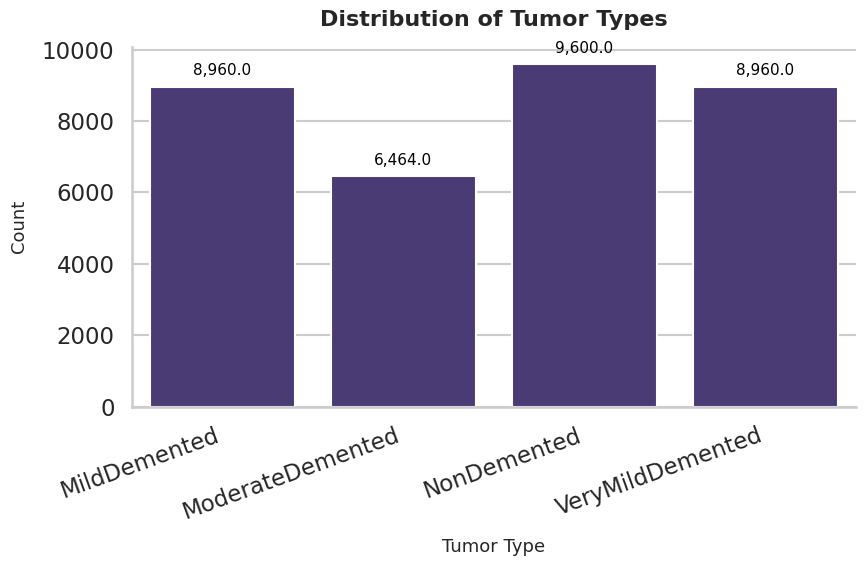

In [14]:
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk", palette="viridis")

fig, ax = plt.subplots(figsize=(9, 6))
sns.countplot(data=df, x="label", ax=ax)
ax.set_title("Distribution of Tumor Types", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Tumor Type", fontsize=13, labelpad=10)
ax.set_ylabel("Count", fontsize=13, labelpad=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:,}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=11, color='black', xytext=(0, 6),
                textcoords='offset points')

sns.despine()
plt.tight_layout()
plt.show()

### Cell 12: Pie chart

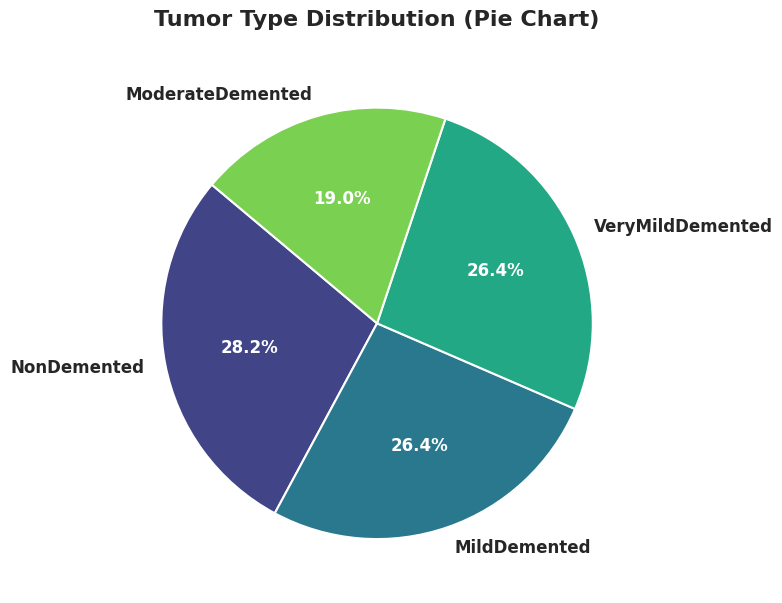

In [15]:
label_counts = df["label"].value_counts()
colors = sns.color_palette("viridis", len(label_counts))

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    label_counts,
    labels=label_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    textprops={'fontsize': 12, 'weight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

for autotext in autotexts:
    autotext.set_color('white')

ax.set_title("Tumor Type Distribution (Pie Chart)", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### Cell 13: Display sample images

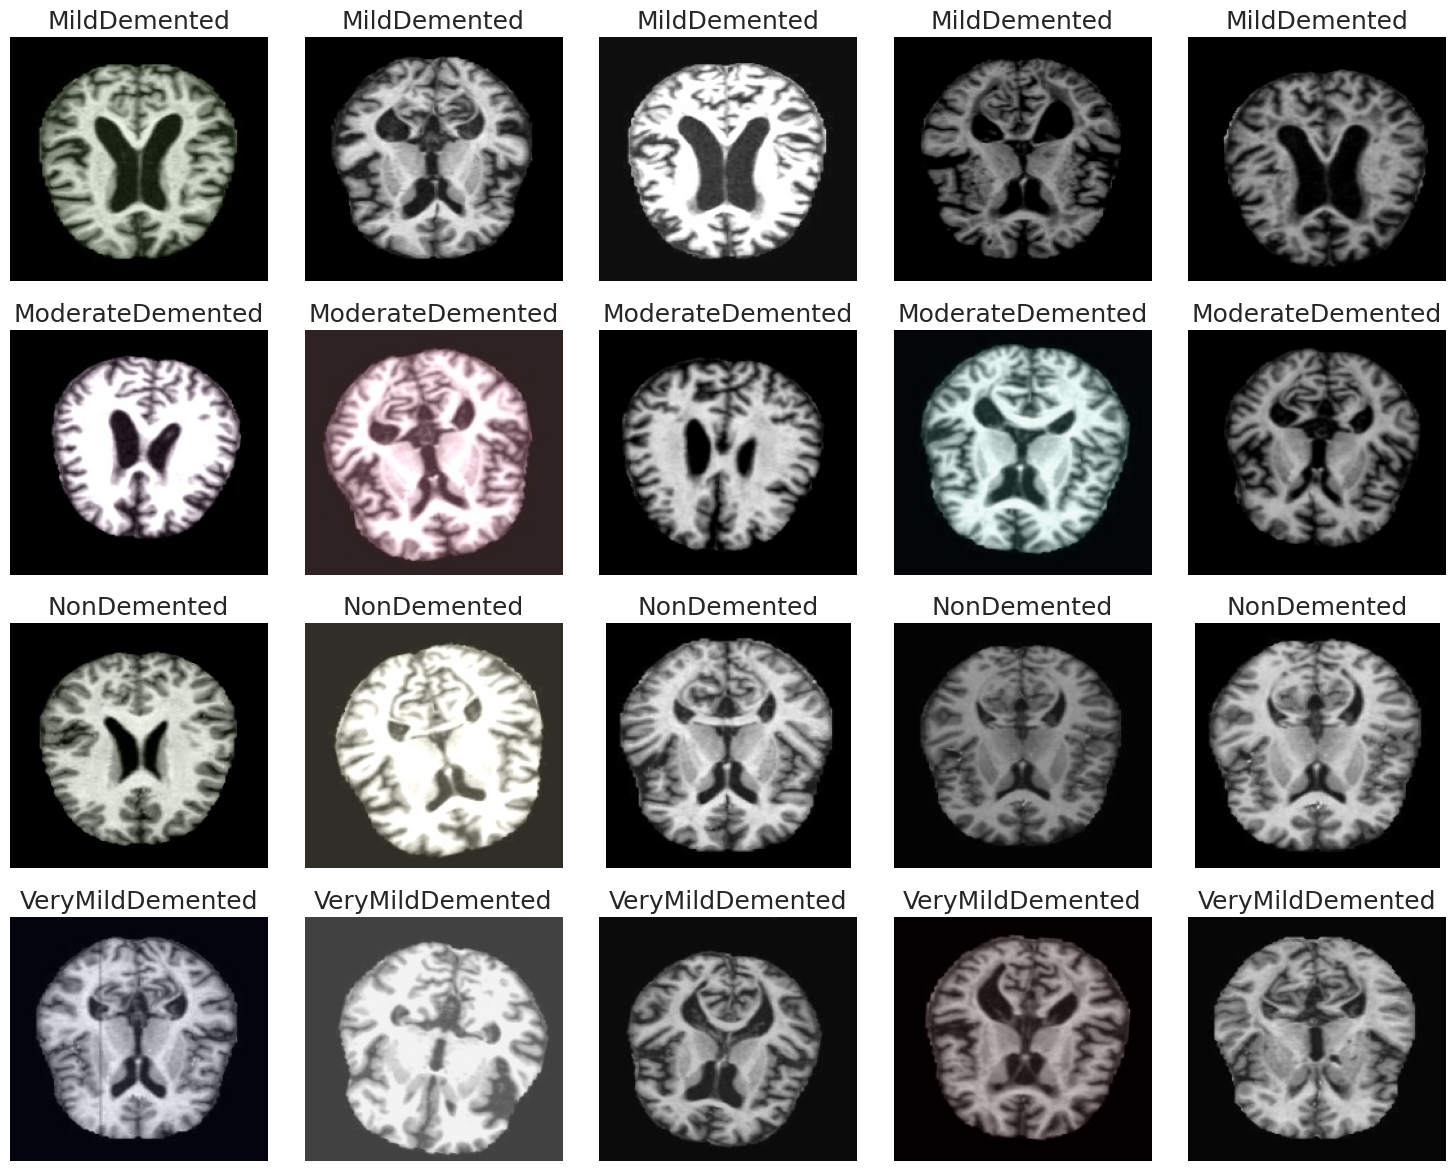

In [16]:
import cv2

num_images = 5
plt.figure(figsize=(15, 12))

for i, category in enumerate(categories):
    category_images = df[df['label'] == category]['image_path'].iloc[:num_images]
    for j, img_path in enumerate(category_images):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(len(categories), num_images, i * num_images + j + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(category)

plt.tight_layout()
plt.show()

### Cell 14: Balance the dataset

In [ ]:
# Balancing is done after train/test split (see below)


,image_path,label
0,unzipped_archive/AugmentedAlzheimerDataset/Mil...,MildDemented
1,unzipped_archive/AugmentedAlzheimerDataset/Mil...,MildDemented
2,unzipped_archive/AugmentedAlzheimerDataset/Mil...,MildDemented
3,unzipped_archive/AugmentedAlzheimerDataset/Mil...,MildDemented
4,unzipped_archive/AugmentedAlzheimerDataset/Mil...,MildDemented
...,...,...
38395,unzipped_archive/AugmentedAlzheimerDataset/Ver...,VeryMildDemented
38396,unzipped_archive/AugmentedAlzheimerDataset/Ver...,VeryMildDemented
38397,unzipped_archive/AugmentedAlzheimerDataset/Ver...,VeryMildDemented
38398,unzipped_archive/AugmentedAlzheimerDataset/Ver...,VeryMildDemented


### Cell 15: Import PyTorch and setup

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from copy import deepcopy

### Cell 16: Define dataset class

In [18]:
class MRIDataset(Dataset):
    def __init__(self, df, transform=None):
        self.paths = df['image_path'].values
        self.labels = pd.Categorical(df['label']).codes.astype(np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

### Cell 17: Setup data transforms and loaders

In [19]:
from sklearn.model_selection import train_test_split

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Split into train and test (no validation)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Balance train set by oversampling minority classes
max_samples = train_df['label'].value_counts().max()
train_df = train_df.groupby('label', group_keys=False).apply(
    lambda x: x.sample(n=max_samples, replace=True, random_state=42)
).reset_index(drop=True)

# Balance test set by oversampling minority classes
max_samples_test = test_df['label'].value_counts().max()
test_df = test_df.groupby('label', group_keys=False).apply(
    lambda x: x.sample(n=max_samples_test, replace=True, random_state=42)
).reset_index(drop=True)

train_ds = MRIDataset(train_df, transform)
test_ds = MRIDataset(test_df, transform)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, pin_memory=True, num_workers=4)
test_loader = DataLoader(test_ds, batch_size=512, shuffle=False, pin_memory=True, num_workers=4)


In [20]:
print(f"Training dataset size: {len(train_ds)}")
print(f"Test dataset size: {len(test_ds)}")


Training dataset size: 30720
Test dataset size: 7680


### Cell 18: Define model

In [21]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

class EfficientNetModel(nn.Module):
    def __init__(self, num_classes=4):
        super(EfficientNetModel, self).__init__()
        # Load pre-trained EfficientNet-B0
        self.efficientnet = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

        # EfficientNet-B0's classifier input features is 1280
        in_features = self.efficientnet.classifier[1].in_features

        # Replace the final linear layer (index 1 of the classifier)
        self.efficientnet.classifier[1] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.efficientnet(x)

### Cell 19: Setup device and model

In [22]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = EfficientNetModel(num_classes=4).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-3)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 159MB/s]


### Cell 20: Define training and evaluation functions

In [23]:
def train_epoch(model, optimizer):
    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

def evaluate(model):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            pred = model(x).argmax(1)
            preds.extend(pred.cpu().numpy())
            trues.extend(y.cpu().numpy())
    return np.mean(np.array(preds) == np.array(trues)), preds, trues

### Cell 21: Train initial model

In [24]:
train_accs, val_accs = [], []
best_val_acc = 0
best_model = None

print("Training for 10 epochs...")
for epoch in range(5):
    train_epoch(model, optimizer)
    acc, preds, trues = evaluate(model)
    train_accs.append(acc)
    val_accs.append(acc)
    if acc > best_val_acc:
        best_val_acc = acc
        best_model = deepcopy(model)
    print(f"Epoch {epoch:02d} | Val Acc: {acc:.4f}")

Training for 10 epochs...
Epoch 00 | Val Acc: 0.9512
Epoch 01 | Val Acc: 0.9646
Epoch 02 | Val Acc: 0.9841
Epoch 03 | Val Acc: 0.9905
Epoch 04 | Val Acc: 0.9849


### Cell 22: Plot training progress

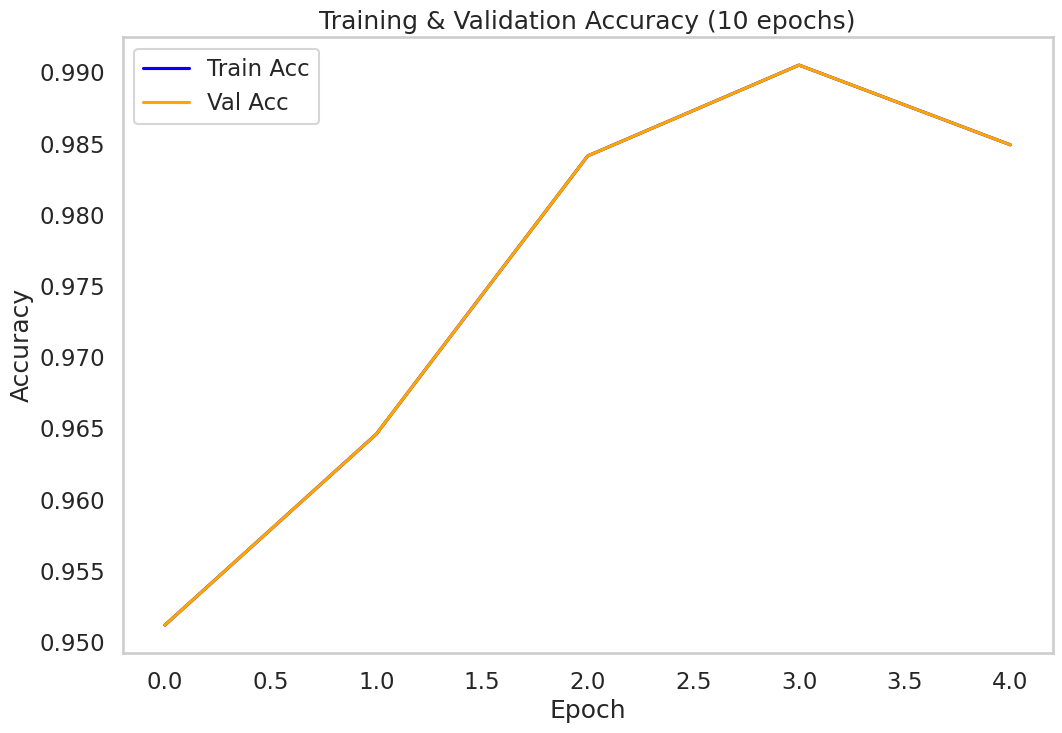

In [25]:
plt.figure(figsize=(12,8))
plt.plot(train_accs, label='Train Acc', color='blue')
plt.plot(val_accs, label='Val Acc', color='orange')
plt.title('Training & Validation Accuracy (10 epochs)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

### Cell 25: Final evaluation and classification report

In [26]:
acc, preds, trues = evaluate(model)
print("\nFINAL CLASSIFICATION REPORT")
print(classification_report(trues, preds, target_names=['Mild','Mod','Non','VeryMild']))


FINAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Mild       0.98      1.00      0.99      1920
         Mod       1.00      1.00      1.00      1920
         Non       0.98      0.97      0.97      1920
    VeryMild       0.99      0.97      0.98      1920

    accuracy                           0.98      7680
   macro avg       0.98      0.98      0.98      7680
weighted avg       0.98      0.98      0.98      7680



### Cell 26: Confusion matrix

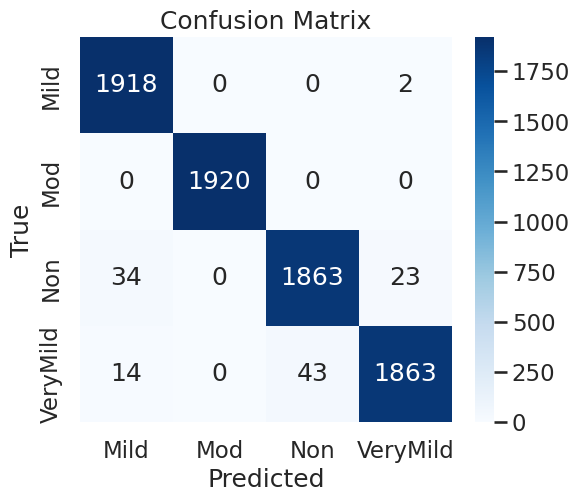

In [27]:
cm = confusion_matrix(trues, preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Mild','Mod','Non','VeryMild'], yticklabels=['Mild','Mod','Non','VeryMild'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

### Cell 27: Calculate final sparsity

In [28]:
sparsity = sum((p.abs() < 1e-3).sum().item() for p in model.parameters() if p.dim() > 1)
total = sum(p.numel() for p in model.parameters() if p.dim() > 1)
print(f"Final Sparsity: {sparsity/total*100:.2f}%")

Final Sparsity: 1.28%


### Cell 28: Plot pruning results comparison

In [29]:
plt.figure(figsize=(10,6))
for th, _, curve in results:
    plt.plot(curve, label=f'th={th}')
plt.title('Post-Prune Accuracy vs Epoch (Lottery Ticket Search)')
plt.xlabel('Fine-tune Epoch')
plt.ylabel('Val Accuracy')
plt.legend()
plt.grid()
plt.show()

NameError: name 'results' is not defined

<Figure size 1000x600 with 0 Axes>

### Cell 29: Save the final model

In [ ]:
model_save_path = '/content/drive/MyDrive/final_pruned_model.pth'
torch.save(model.state_dict(), model_save_path)
print(f"Final pruned model saved to {model_save_path}")

In [ ]:
# جرب تحميله الآن في خلية جديدة
import torch
try:
    test_model = torch.load('/content/drive/MyDrive/final_pruned_model.pth')
    print("تم التحقق: الملف سليم وقابل للتحميل!")
except Exception as e:
    print(f"هناك مشكلة في التحميل: {e}")

### Cell X: Test the model with a sample image


In [ ]:
import torch
from PIL import Image
from torchvision import transforms
import pandas as pd
import numpy as np

# Assuming the EfficientNetModel class and transform are already defined and in scope
# If not, they would need to be re-defined here or loaded from a separate script.

# Re-initialize the model structure
model_test = ResNetModel(num_classes=4).to(device) # Changed from EfficientNetModel to ResNetModel

# Load the saved state dictionary
model_test.load_state_dict(torch.load(model_save_path))
model_test.eval() # Set model to evaluation mode

# Define the labels in the same order as they were encoded during training
label_map = {
    'MildDemented': 0,
    'ModerateDemented': 1,
    'NonDemented': 2,
    'VeryMildDemented': 3
}
reverse_label_map = {v: k for k, v in label_map.items()}

# Get a sample image path and its true label (for comparison)
sample_image_path = df['image_path'].iloc[0] # Taking the first image from the dataframe
sample_true_label_encoded = df['label'].iloc[0] # Get the string label

print(f"Sample image path: {sample_image_path}")
print(f"True label: {sample_true_label_encoded}")

# Load and transform the image
img = Image.open(sample_image_path).convert('RGB')
input_tensor = transform(img).unsqueeze(0).to(device) # Add batch dimension and move to device

# Make a prediction
with torch.no_grad():
    output = model_test(input_tensor)
    probabilities = torch.softmax(output, dim=1)
    predicted_class_idx = torch.argmax(probabilities, dim=1).item()
    predicted_probability = probabilities[0, predicted_class_idx].item()

predicted_label = reverse_label_map[predicted_class_idx]

print(f"Predicted label: {predicted_label}")
print(f"Predicted probability: {predicted_probability:.4f}")

# Optional: Display the image
# plt.imshow(img)
# plt.title(f"True: {sample_true_label_encoded}, Predicted: {predicted_label}")
# plt.axis('off')
# plt.show()